In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss
import warnings
warnings.filterwarnings('ignore')

# Setting random seed for reproducibility
np.random.seed(42)

In [ ]:
def generate_dataset(n_samples, n_features, n_informative, class_sep=1.0, flip_y=0.0):
    """Generate synthetic binary classification dataset"""
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_informative,
        n_redundant=n_features - n_informative,
        n_clusters_per_class=2,
        class_sep=class_sep,
        flip_y=flip_y,
        random_state=42
    )
    return train_test_split(X, y, test_size=0.2, random_state=42)

def train_epoch_by_epoch(solver, X_train, y_train, X_test, y_test,
                        n_epochs=100, track_weights=False, initial_weights=None):
    """Train model epoch by epoch and track metrics"""
    train_losses = []
    test_losses = []
    weights_history = []

    # Standardize the data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    start_time = time.time()

    if solver == 'sgd':
        # Use SGDClassifier for SGD with better learning rate
        model = SGDClassifier(
            loss='log_loss',
            learning_rate='constant',
            eta0=0.01,  # Learning rate
            max_iter=1,
            tol=None,
            random_state=42,
            warm_start=True,
            fit_intercept=True
        )

        # Initialize with partial_fit for the first epoch
        classes = np.unique(y_train)

        # Better initialization: small random weights
        if initial_weights is not None:
            # Initialize the model first
            model.partial_fit(X_train_scaled[:1], y_train[:1], classes=classes)
            model.coef_[0] = initial_weights.copy()
            model.intercept_[0] = 0.0
        else:
            model.partial_fit(X_train_scaled, y_train, classes=classes)

        # Record initial weights before training
        if track_weights and X_train.shape[1] == 2:
            weights_history.append(model.coef_[0].copy())

        for epoch in range(n_epochs):
            # Shuffle data for each epoch
            indices = np.random.permutation(len(X_train_scaled))
            X_shuffled = X_train_scaled[indices]
            y_shuffled = y_train[indices]

            model.partial_fit(X_shuffled, y_shuffled)

            # Calculate losses
            train_proba = model.predict_proba(X_train_scaled)
            test_proba = model.predict_proba(X_test_scaled)
            train_loss = log_loss(y_train, train_proba)
            test_loss = log_loss(y_test, test_proba)

            train_losses.append(train_loss)
            test_losses.append(test_loss)

            if track_weights and X_train.shape[1] == 2:
                weights_history.append(model.coef_[0].copy())

    else:
        model = LogisticRegression(
            solver=solver,
            max_iter=n_epochs,  # Let it run for full epochs
            warm_start=True,
            random_state=42,
            tol=1e-10,
            fit_intercept=True
        )

        model.fit(X_train_scaled, y_train)  # Initial fit to set up the model

        # Set initial weights if provided
        if initial_weights is not None:
            model.coef_ = initial_weights.reshape(1, -1).copy()

        if track_weights and X_train.shape[1] == 2:
            weights_history.append(model.coef_[0].copy())

        # Train for one epoch at a time by controlling max_iter
        for epoch in range(n_epochs):
            if initial_weights is not None:
                model.coef_ = initial_weights.reshape(1, -1).copy()
                model.intercept_ = np.array([0.0])

            model.max_iter = epoch + 1
            model.fit(X_train_scaled, y_train)

            # Calculate losses
            train_proba = model.predict_proba(X_train_scaled)
            test_proba = model.predict_proba(X_test_scaled)
            train_loss = log_loss(y_train, train_proba)
            test_loss = log_loss(y_test, test_proba)

            train_losses.append(train_loss)
            test_losses.append(test_loss)

            if track_weights and X_train.shape[1] == 2:
                weights_history.append(model.coef_[0].copy())

    training_time = time.time() - start_time

    # Final accuracy
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    return {
        'train_losses': train_losses,
        'test_losses': test_losses,
        'training_time': training_time,
        'final_test_loss': test_losses[-1],
        'accuracy': accuracy,
        'weights_history': weights_history if track_weights else None,
        'model': model,
        'scaler': scaler
    }


In [ ]:
# Part 1: Convergence and Scalability Analysis
print("Part 1: Convergence and Scalability Analysis")
print("-" * 50)

sample_sizes = [500, 5000, 20000]
solvers = ['sgd', 'sag', 'saga']
solver_names = {'sgd': 'SGD', 'sag': 'SAG', 'saga': 'SAGA'}

results = {}

for n in sample_sizes:
    print(f"\nProcessing n={n} samples...")
    X_train, X_test, y_train, y_test = generate_dataset(
        n_samples=n,
        n_features=20,
        n_informative=10
    )

    results[n] = {}

    np.random.seed(42)
    initial_weights = np.random.randn(X_train.shape[1]) * 0.01  # Small random initialization

    for solver in solvers:
        print(f"  Training with {solver_names[solver]}...")
        result = train_epoch_by_epoch(
            solver=solver,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            initial_weights=initial_weights if solver == 'sgd' else None,
            n_epochs=100
        )
        results[n][solver] = result

Part 1: Convergence and Scalability Analysis
--------------------------------------------------

Processing n=500 samples...
  Training with SGD...
  Training with SAG...
  Training with SAGA...

Processing n=5000 samples...
  Training with SGD...
  Training with SAG...
  Training with SAGA...

Processing n=20000 samples...
  Training with SGD...
  Training with SAG...
  Training with SAGA...


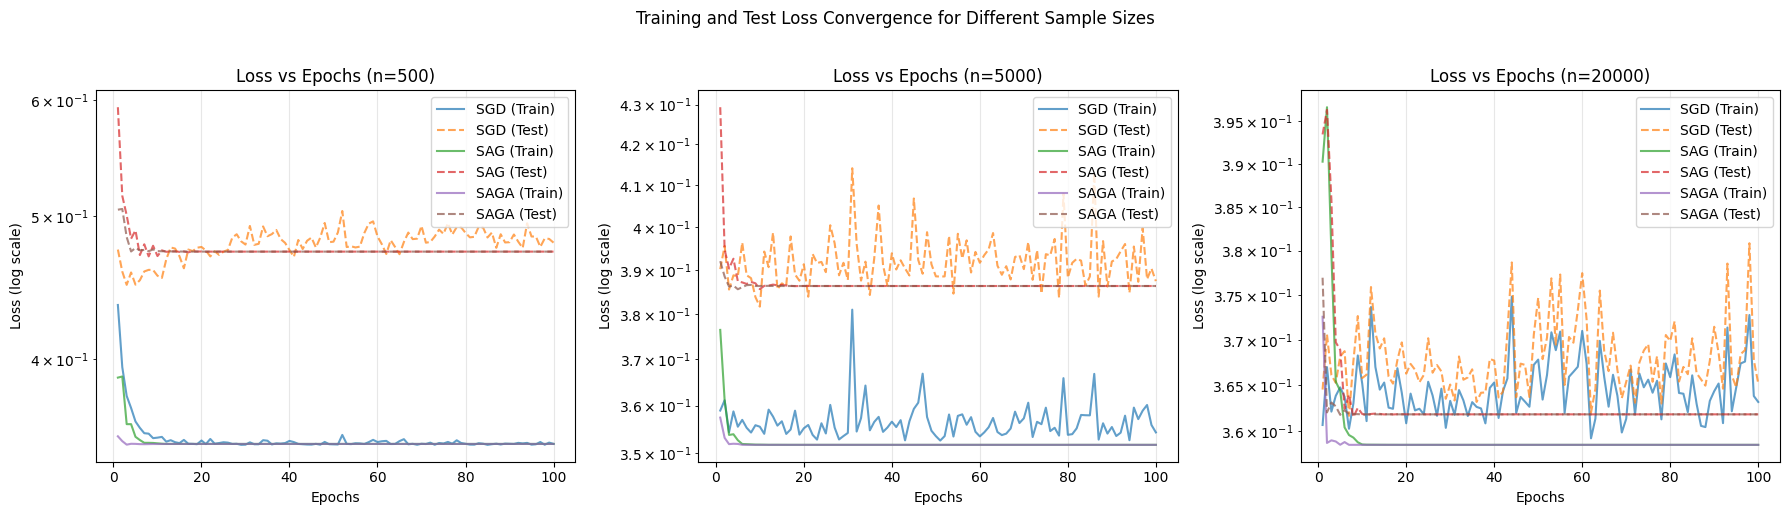

In [ ]:
# Create Plots 1-3: Loss vs Epochs for each sample size
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, n in enumerate(sample_sizes):
    ax = axes[idx]

    for solver in solvers:
        epochs = np.arange(1, len(results[n][solver]['train_losses']) + 1)
        train_losses = results[n][solver]['train_losses']
        test_losses = results[n][solver]['test_losses']

        ax.semilogy(epochs, train_losses, label=f'{solver_names[solver]} (Train)',
                   linestyle='-', alpha=0.7)
        ax.semilogy(epochs, test_losses, label=f'{solver_names[solver]} (Test)',
                   linestyle='--', alpha=0.7)

    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss (log scale)')
    ax.set_title(f'Loss vs Epochs (n={n})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training and Test Loss Convergence for Different Sample Sizes', y=1.02)
plt.tight_layout()
plt.show()

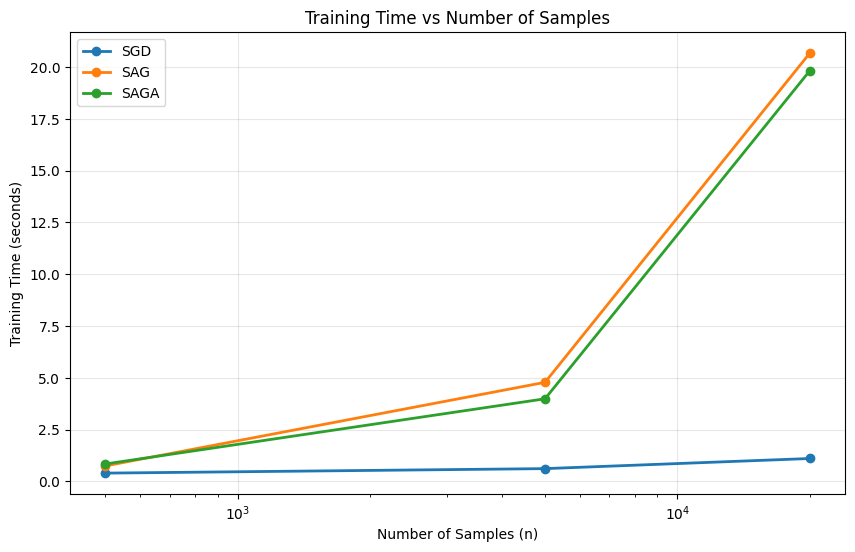


Part 2: Optimization Path Visualization
--------------------------------------------------


In [ ]:
# Plot 4: Training Time vs Number of Samples
fig, ax = plt.subplots(figsize=(10, 6))

for solver in solvers:
    times = [results[n][solver]['training_time'] for n in sample_sizes]
    ax.plot(sample_sizes, times, marker='o', label=solver_names[solver], linewidth=2)

ax.set_xlabel('Number of Samples (n)')
ax.set_ylabel('Training Time (seconds)')
ax.set_title('Training Time vs Number of Samples')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
plt.show()

# Part 2: Optimization Path Visualization
print("\nPart 2: Optimization Path Visualization")
print("-" * 50)

In [ ]:
# Create contour plot of loss surface
def compute_loss_surface(X, y, w1_range, w2_range, scaler):
    """Compute logistic loss over a grid of weights"""
    X_scaled = scaler.transform(X)
    W1, W2 = np.meshgrid(w1_range, w2_range)
    Z = np.zeros_like(W1)

    for i in range(W1.shape[0]):
        for j in range(W1.shape[1]):
            w = np.array([W1[i, j], W2[i, j]])
            z = X_scaled @ w
            # Clip to prevent overflow
            z = np.clip(z, -500, 500)
            proba = 1 / (1 + np.exp(-z))
            proba = np.clip(proba, 1e-15, 1 - 1e-15)
            loss = -np.mean(y * np.log(proba) + (1 - y) * np.log(1 - proba))
            Z[i, j] = loss

    return W1, W2, Z

Training SGD on 2D dataset...
Training SAG on 2D dataset...
Training SAGA on 2D dataset...


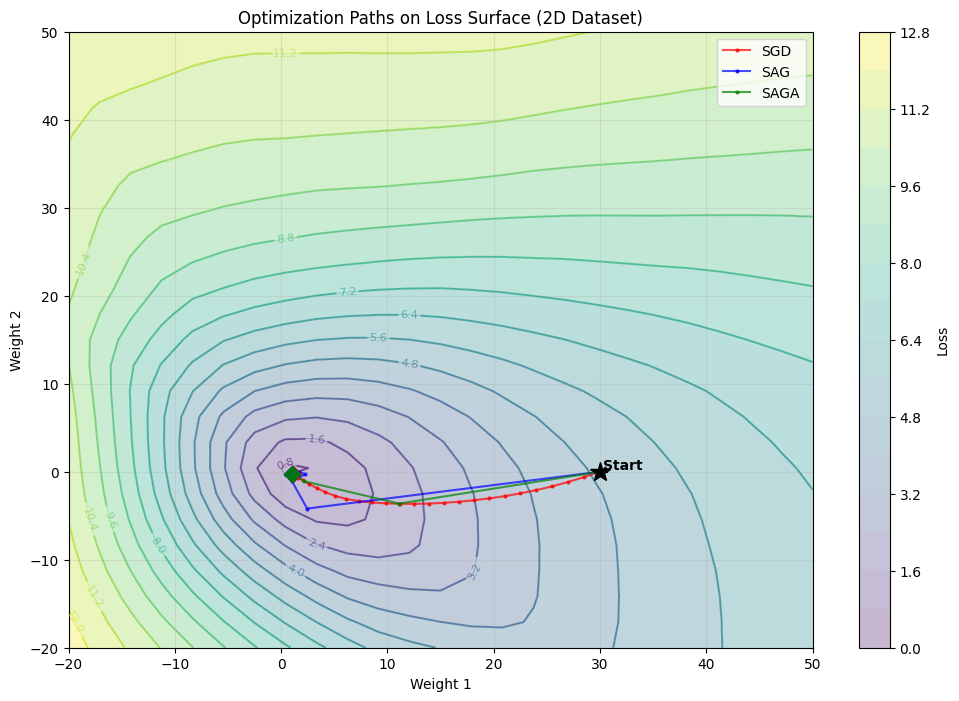

In [ ]:
# Generate 2D dataset for visualization
# generate noisy 2D dataset
X_train_2d, X_test_2d, y_train_2d, y_test_2d = generate_dataset(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    # flip_y=0.5,
    class_sep=0.4,
)

# After generating data
# X_train_2d += np.random.normal(10, 15, X_train_2d.shape)  # Add Gaussian noise

# Define a better starting point for all optimizers
np.random.seed(42)
initial_weights = np.array([30, 0])  # Better starting point closer to zero

# Train models and track weights with same initialization
results_2d = {}
for solver in solvers:
    print(f"Training {solver_names[solver]} on 2D dataset...")
    result = train_epoch_by_epoch(
        solver=solver,
        X_train=X_train_2d,
        y_train=y_train_2d,
        X_test=X_test_2d,
        y_test=y_test_2d,
        n_epochs=50,
        track_weights=True,
        initial_weights=initial_weights
    )
    results_2d[solver] = result

# Plot 5: Contour plot with optimization paths
fig, ax = plt.subplots(figsize=(12, 8))

# Use the scaler from one of the models
scaler = results_2d['sgd']['scaler']

# Define weight ranges for contour plot
w1_range = np.linspace(-20, 50, 25)
w2_range = np.linspace(-20, 50, 25)

W1, W2, Z = compute_loss_surface(X_train_2d, y_train_2d, w1_range, w2_range, scaler)

# Plot contour
contour = ax.contour(W1, W2, Z, levels=15, alpha=0.6)
ax.clabel(contour, inline=True, fontsize=8)
contourf = ax.contourf(W1, W2, Z, levels=15, alpha=0.3, cmap='viridis')
plt.colorbar(contourf, ax=ax, label='Loss')

# Plot optimization paths
colors = {'sgd': 'red', 'sag': 'blue', 'saga': 'green'}
for solver in solvers:
    weights = np.array(results_2d[solver]['weights_history'])
    if len(weights) > 0:
        # Plot the path
        ax.plot(weights[:, 0], weights[:, 1],
               color=colors[solver],
               marker='o',
               markersize=2,
               linewidth=1.5,
               label=solver_names[solver],
               alpha=0.7)

        # Mark starting point
        if solver == 'sgd':  # Only mark once
            ax.plot(weights[0, 0], weights[0, 1],
                   color='black',
                   marker='*',
                   markersize=15,
                   zorder=10)

        # Mark ending point
        ax.plot(weights[-1, 0], weights[-1, 1],
               color=colors[solver],
               marker='D',
               markersize=8,
               alpha=0.9,
               zorder=9)

# Add annotation for starting point
if len(results_2d) > 0 and len(results_2d['sgd']['weights_history']) > 0:
    first_weights = np.array(results_2d['sgd']['weights_history'])[0]
    ax.annotate('Start',
                xy=(first_weights[0], first_weights[1]),
                xytext=(first_weights[0] + 0.3, first_weights[1] + 0.3),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=10,
                fontweight='bold')

ax.set_xlabel('Weight 1')
ax.set_ylabel('Weight 2')
ax.set_title('Optimization Paths on Loss Surface (2D Dataset)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Table 1: Summary for n=20000
print("\nTable 1: Summary Results for n=20000")
print("-" * 60)

summary_data = []
for solver in solvers:
    result = results[20000][solver]
    summary_data.append({
        'Optimizer': solver_names[solver],
        'Training Time (s)': f"{result['training_time']:.2f}",
        'Final Test Loss': f"{result['final_test_loss']:.4f}",
        'Test Accuracy (%)': f"{result['accuracy']*100:.2f}"
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))


Table 1: Summary Results for n=20000
------------------------------------------------------------
Optimizer Training Time (s) Final Test Loss Test Accuracy (%)
      SGD              1.11          0.3652             83.10
      SAG             20.67          0.3618             83.17
     SAGA             19.82          0.3618             83.17
